# Subchallenges I-II (including gold standards)

In [ ]:
import pandas as pd
# load cytof
df = pd.read_csv('./data/cytof.csv', index_col=0)
# subset to pAKT and pS6
df = df[df['observableId'].isin(['p.AKT.Thr308.', 'p.Akt.Ser473.', 'p.S6'])]
df['preequilibrationConditionId'] = df['preequilibrationConditionId'].apply(lambda x: x[1:])
# subset to cell lines (exclude full media conditions)
cell_lines = [c for c in df['preequilibrationConditionId'].unique() if not c.endswith('full')]
df = df[df['preequilibrationConditionId'].isin(cell_lines)]
df['treatment'] = df['simulationConditionId'].str.split('__').str[1]
# subset to EGF, iPI3K
df = df[df['treatment'].isin(['EGF', 'iPI3K'])]

# load annotations
annotation = pd.read_csv('./cell_line_subtypes.txt', index_col=0, sep='\t')

def get_lineage(x):
    # Normalize the preequilibration ID for lookup
    key = x.lower().replace('mpe600', '600mpe')

    # Force DU4475 subtype to Basal
    if 'du4475' in key:
        subtype = 'Basal'
    else:
        subtype = annotation.loc[key, 'subtype_intrinsic']

    # Map subtype to lineage
    return {
        "LuminalA": 'luminal',
        "LuminalB": 'luminal',
        "HER2": 'luminal',
        "Basal": 'basal',
        "CL": 'basal',
        "Normal": 'normal'
    }.get(subtype)

df['lineage'] = df['preequilibrationConditionId'].apply(get_lineage)

print("Number of unique cell-lines: ", df.preequilibrationConditionId.nunique())

# count number of non-nan measurements per group
df['isna'] = df['measurement'].isna().astype('float') + 1

print("Number of Normal cell-lines: ", df[df.lineage == "normal"].preequilibrationConditionId.nunique())
df = df[df['lineage'] != 'normal']
print("Number of non-Normal cell-lines: ", df.preequilibrationConditionId.nunique())
print("of which Luminal cell-lines: ", df[df.lineage == "luminal"].preequilibrationConditionId.nunique())
print("and Basal cell-lines: ", df[df.lineage == "basal"].preequilibrationConditionId.nunique())

df['treatment'] = df['treatment'].replace('iPI3K', 'EGF + pictilisib')


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# aggregate mean and std per lineage
dfp = (
    df[['treatment', 'time', 'observableId', 'lineage', 'measurement', 'isna']]
    .groupby(['treatment', 'time', 'observableId', 'lineage'])
    .agg(measurement_mean=('measurement', 'mean'),
         measurement_std=('measurement', 'std'),
         n=('measurement', 'count'),
         isna=('isna', 'sum'))
    .reset_index()
)

dfp['measurement_se'] = dfp['measurement_std'] / np.sqrt(dfp['n'])

# filter data
dfp_filtered = dfp[dfp['isna'] >= 4]

dfp_filtered['lineage'] = dfp_filtered['lineage'].str.capitalize()

# create FacetGrid
g = sns.FacetGrid(
    data=dfp_filtered,
    row="lineage",
    row_order=["Luminal", "Basal"],
    col="observableId",
    margin_titles=True,
    sharey=False,
)

# map lineplots
def plot_with_shading(data, **kwargs):
    ax = plt.gca()
    for treatment, subdf in data.groupby("treatment"):
        ax.plot(subdf["time"], subdf["measurement_mean"], label=treatment)
        ax.fill_between(
            subdf["time"],
            subdf["measurement_mean"] - subdf["measurement_se"],
            subdf["measurement_mean"] + subdf["measurement_se"],
            alpha=0.2
        )

g.map_dataframe(plot_with_shading)
# Fix title templates
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Add axis labels
for ax in g.axes[-1, :]:  # bottom row
    ax.set_xlabel("Time")

for ax in g.axes[:, 0]:  # leftmost column
    ax.set_ylabel("Response")
g.add_legend()
plt.savefig("updated_response_AKT_S6_PI3Ki_LuminalvsBasal.pdf")

# Adding cell-lines from subchallenge IV (directly from population-level gold standard)

In [1]:
import pandas as pd
# load cytof
df = pd.read_csv('./data/cytof.csv', index_col=0)
gs4 = pd.read_csv('./data/sc4gold.csv', index_col=0)

# Prepare dataframe from subchallenges I-II
# subset to cell lines (exclude full media conditions)
cell_lines = [c for c in df['preequilibrationConditionId'].unique() if not c.endswith('full')]
df = df[df['preequilibrationConditionId'].isin(cell_lines)]
# Get treatment info
df['treatment'] = df['simulationConditionId'].str.split('__').str[1]
# Remove c prefix to get readable cell-line names
df['preequilibrationConditionId'] = df['preequilibrationConditionId'].apply(lambda x: x[1:])

# Prepare gold standard subchallenge IV
gs4_useful_long = gs4.reset_index().melt(
    id_vars=["cell_line", "treatment", "time"],
    var_name="observableId",
    value_name="measurement",
).rename(columns={"cell_line": "preequilibrationConditionId"}).assign(measurementType="cytof")
gs4_useful_long["FEATURE_ID"] = gs4_useful_long["observableId"]
gs4_useful_long["simulationConditionId"] = gs4_useful_long["preequilibrationConditionId"] + "__" + gs4_useful_long["treatment"]

# Concatenate
df_new = pd.concat([df, gs4_useful_long], axis=0)
# subset to pAKT and pS6
df_new = df_new[df_new['observableId'].isin(['p.AKT.Thr308.', 'p.Akt.Ser473.', 'p.S6'])]
# subset to EGF and PI3Ki conditions
df_new = df_new[df_new['treatment'].isin(['EGF', 'iPI3K'])]

In [2]:
df_new.preequilibrationConditionId.nunique()

67

In [3]:
# load annotations
annotation = pd.read_csv('./cell_line_subtypes.txt', index_col=0, sep='\t')

def get_lineage(x):
    # Normalize the preequilibration ID for lookup
    key = x.lower().replace('mpe600', '600mpe')

    # Add missing subtypes according to Cellosaurus & literature
    if 'du4475' in key:
        subtype = 'Basal'
    elif 'hcc2157' in key:
        subtype = 'Basal'
    elif 'mdakb2' in key:
        subtype = 'Basal'
    elif 'macls2' in key:
        subtype = 'Basal'
    elif 'hdqp1' in key:
        subtype = "Basal"
    elif "mcf10f" in key:
        subtype = "Normal"
    else:
        subtype = annotation.loc[key, 'subtype_intrinsic']

    # Map subtype to lineage
    return {
        "LuminalA": 'luminal',
        "LuminalB": 'luminal',
        "HER2": 'luminal',
        "Basal": 'basal',
        "CL": 'basal',
        "Normal": 'normal'
    }.get(subtype)

df_new['lineage'] = df_new['preequilibrationConditionId'].apply(get_lineage)

# Count number of unique cell-lines
print("Number of unique cell-lines: ", df_new.preequilibrationConditionId.nunique())

# Count number of non-nan measurements per group
df_new['isna'] = df_new['measurement'].isna().astype('float') + 1

# Count Normal, Luminal and Basal
print("Number of Normal cell-lines: ", df_new[df_new.lineage == "normal"].preequilibrationConditionId.nunique())
print(df_new[df_new.lineage == "normal"].preequilibrationConditionId.unique())
df_new = df_new[df_new['lineage'] != 'normal']
print("Number of non-Normal cell-lines: ", df_new.preequilibrationConditionId.nunique())
print("of which Luminal cell-lines: ", df_new[df_new.lineage == "luminal"].preequilibrationConditionId.nunique())
print("and Basal cell-lines: ", df_new[df_new.lineage == "basal"].preequilibrationConditionId.nunique())

df_new['treatment'] = df_new['treatment'].replace('iPI3K', 'EGF + pictilisib')

Number of unique cell-lines:  67
Number of Normal cell-lines:  5
['184A1' '184B5' 'MCF10A' 'MCF10F' 'MCF12A']
Number of non-Normal cell-lines:  62
of which Luminal cell-lines:  33
and Basal cell-lines:  29


In [4]:
df_new.preequilibrationConditionId.nunique()

62

/var/folders/qq/j5fqpnkx00n96n4y5_rx_f7r0000gp/T/ipykernel_32384/1096205730.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfp_filtered['lineage'] = dfp_filtered['lineage'].str.capitalize()


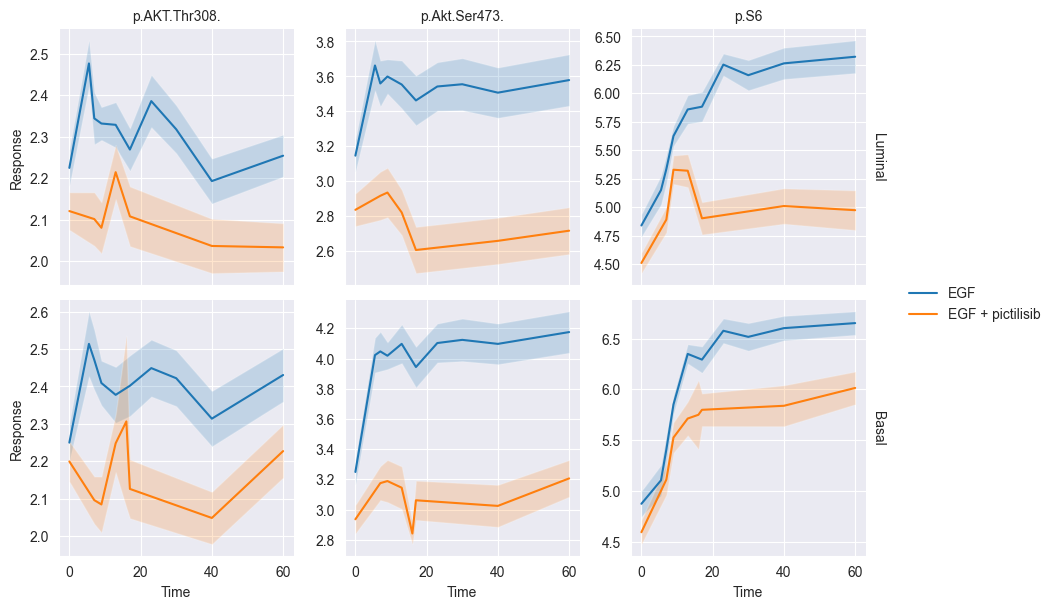

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# aggregate mean and std per lineage
dfp = (
    df_new[['treatment', 'time', 'observableId', 'lineage', 'measurement', 'isna']]
    .groupby(['treatment', 'time', 'observableId', 'lineage'])
    .agg(measurement_mean=('measurement', 'mean'),
         measurement_std=('measurement', 'std'),
         n=('measurement', 'count'),
         isna=('isna', 'sum'))
    .reset_index()
)

dfp['measurement_se'] = dfp['measurement_std'] / np.sqrt(dfp['n'])

# filter data
dfp_filtered = dfp[dfp['isna'] >= 4]

dfp_filtered['lineage'] = dfp_filtered['lineage'].str.capitalize()

# create FacetGrid
g = sns.FacetGrid(
    data=dfp_filtered,
    row="lineage",
    row_order=["Luminal", "Basal"],
    col="observableId",
    margin_titles=True,
    sharey=False,
)

# map lineplots
def plot_with_shading(data, **kwargs):
    ax = plt.gca()
    for treatment, subdf in data.groupby("treatment"):
        ax.plot(subdf["time"], subdf["measurement_mean"], label=treatment)
        ax.fill_between(
            subdf["time"],
            subdf["measurement_mean"] - subdf["measurement_se"],
            subdf["measurement_mean"] + subdf["measurement_se"],
            alpha=0.2
        )

g.map_dataframe(plot_with_shading)
# Fix title templates
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Add axis labels
for ax in g.axes[-1, :]:  # bottom row
    ax.set_xlabel("Time")

for ax in g.axes[:, 0]:  # leftmost column
    ax.set_ylabel("Response")
g.add_legend()
# plt.savefig("updated_response_AKT_S6_PI3Ki_33Luminalvs29Basal.pdf")

# Keep Luminal / HER2 / Basal (including Claudin Low) distinction

In [11]:
import pandas as pd
# load cytof
df = pd.read_csv('./data/cytof.csv', index_col=0)
gs4 = pd.read_csv('./data/sc4gold.csv', index_col=0)

# Prepare dataframe from subchallenges I-II
# subset to cell lines (exclude full media conditions)
cell_lines = [c for c in df['preequilibrationConditionId'].unique() if not c.endswith('full')]
df = df[df['preequilibrationConditionId'].isin(cell_lines)]
# Get treatment info
df['treatment'] = df['simulationConditionId'].str.split('__').str[1]
# Remove c prefix to get readable cell-line names
df['preequilibrationConditionId'] = df['preequilibrationConditionId'].apply(lambda x: x[1:])

# Prepare gold standard subchallenge IV
gs4_useful_long = gs4.reset_index().melt(
    id_vars=["cell_line", "treatment", "time"],
    var_name="observableId",
    value_name="measurement",
).rename(columns={"cell_line": "preequilibrationConditionId"}).assign(measurementType="cytof")
gs4_useful_long["FEATURE_ID"] = gs4_useful_long["observableId"]
gs4_useful_long["simulationConditionId"] = gs4_useful_long["preequilibrationConditionId"] + "__" + gs4_useful_long["treatment"]

# Concatenate
df_new = pd.concat([df, gs4_useful_long], axis=0)
# subset to pAKT and pS6
df_new = df_new[df_new['observableId'].isin(['p.AKT.Thr308.', 'p.Akt.Ser473.', 'p.S6'])]
# subset to EGF and PI3Ki conditions
df_new = df_new[df_new['treatment'].isin(['EGF', 'iPI3K'])]

In [12]:
df_new.preequilibrationConditionId.nunique()

67

In [13]:
# load annotations
annotation = pd.read_csv('./cell_line_subtypes.txt', index_col=0, sep='\t')

def get_lineage(x):
    # Normalize the preequilibration ID for lookup
    key = x.lower().replace('mpe600', '600mpe')

    # Add missing subtypes according to Cellosaurus & literature
    if 'du4475' in key:
        subtype = 'Basal'
    elif 'hcc2157' in key:
        subtype = 'Basal'
    elif 'mdakb2' in key:
        subtype = 'Basal'
    elif 'macls2' in key:
        subtype = 'Basal'
    elif 'hdqp1' in key:
        subtype = "Basal"
    elif "mcf10f" in key:
        subtype = "Normal"
    else:
        subtype = annotation.loc[key, 'subtype_intrinsic']

    # Map subtype to lineage
    return {
        "LuminalA": 'luminal',  # group Luminal A and B together
        "LuminalB": 'luminal',  # group Luminal A and B together
        "HER2": 'HER2+',
        "Basal": 'basal',
        "CL": 'basal',  # include in TNBC/Basal
        "Normal": 'normal'
    }.get(subtype)

df_new['lineage'] = df_new['preequilibrationConditionId'].apply(get_lineage)

# Count number of unique cell-lines
print("Number of unique cell-lines: ", df_new.preequilibrationConditionId.nunique())

# Count number of non-nan measurements per group
df_new['isna'] = df_new['measurement'].isna().astype('float') + 1

# Count Normal, Luminal and Basal
print("Number of Normal cell-lines: ", df_new[df_new.lineage == "normal"].preequilibrationConditionId.nunique())
print(df_new[df_new.lineage == "normal"].preequilibrationConditionId.unique())
df_new = df_new[df_new['lineage'] != 'normal']
print("Number of non-Normal cell-lines: ", df_new.preequilibrationConditionId.nunique())
print("of which Luminal cell-lines: ", df_new[df_new.lineage == "luminal"].preequilibrationConditionId.nunique())
print("HER2+ cell-lines: ", df_new[df_new.lineage == "HER2+"].preequilibrationConditionId.nunique())
print("and Basal (+ claudin low) cell-lines: ", df_new[df_new.lineage == "basal"].preequilibrationConditionId.nunique())

df_new['treatment'] = df_new['treatment'].replace('iPI3K', 'EGF + pictilisib')

Number of unique cell-lines:  67
Number of Normal cell-lines:  5
['184A1' '184B5' 'MCF10A' 'MCF10F' 'MCF12A']
Number of non-Normal cell-lines:  62
of which Luminal cell-lines:  25
HER2+ cell-lines:  8
and Basal (+ claudin low) cell-lines:  29


In [14]:
df_new.preequilibrationConditionId.nunique()

62

/var/folders/qq/j5fqpnkx00n96n4y5_rx_f7r0000gp/T/ipykernel_33848/3551999770.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfp_filtered['lineage'] = dfp_filtered['lineage'].str.capitalize()
/var/folders/qq/j5fqpnkx00n96n4y5_rx_f7r0000gp/T/ipykernel_33848/3551999770.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfp_filtered["lineage"] = dfp_filtered["lineage"].replace("Her2+", "HER2+")


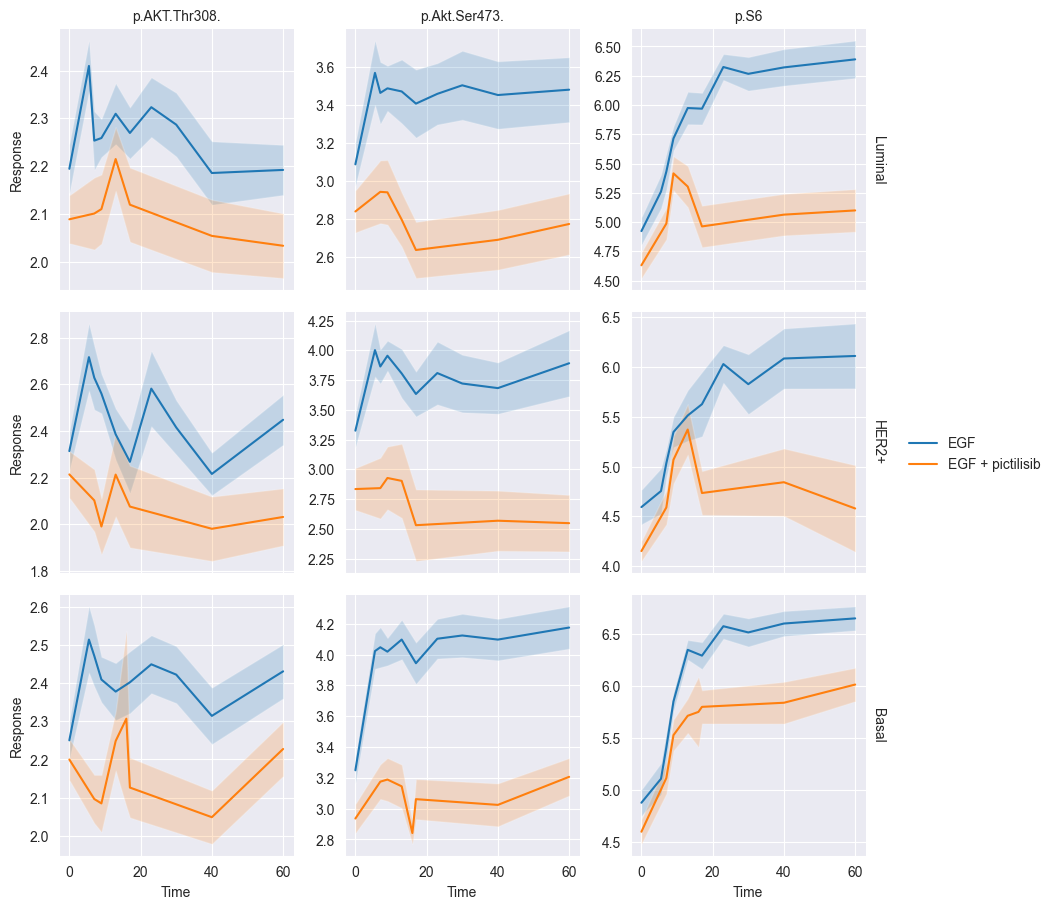

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# aggregate mean and std per lineage
dfp = (
    df_new[['treatment', 'time', 'observableId', 'lineage', 'measurement', 'isna']]
    .groupby(['treatment', 'time', 'observableId', 'lineage'])
    .agg(measurement_mean=('measurement', 'mean'),
         measurement_std=('measurement', 'std'),
         n=('measurement', 'count'),
         isna=('isna', 'sum'))
    .reset_index()
)

dfp['measurement_se'] = dfp['measurement_std'] / np.sqrt(dfp['n'])

# filter data
dfp_filtered = dfp[dfp['isna'] >= 4]

dfp_filtered['lineage'] = dfp_filtered['lineage'].str.capitalize()
dfp_filtered["lineage"] = dfp_filtered["lineage"].replace("Her2+", "HER2+")

# create FacetGrid
g = sns.FacetGrid(
    data=dfp_filtered,
    row="lineage",
    row_order=["Luminal", "HER2+", "Basal"],
    col="observableId",
    margin_titles=True,
    sharey=False,
)

# map lineplots
def plot_with_shading(data, **kwargs):
    ax = plt.gca()
    for treatment, subdf in data.groupby("treatment"):
        ax.plot(subdf["time"], subdf["measurement_mean"], label=treatment)
        ax.fill_between(
            subdf["time"],
            subdf["measurement_mean"] - subdf["measurement_se"],
            subdf["measurement_mean"] + subdf["measurement_se"],
            alpha=0.2
        )

g.map_dataframe(plot_with_shading)
# Fix title templates
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Add axis labels
for ax in g.axes[-1, :]:  # bottom row
    ax.set_xlabel("Time")

for ax in g.axes[:, 0]:  # leftmost column
    ax.set_ylabel("Response")
g.add_legend()
plt.savefig("updated_response_AKT_S6_PI3Ki_25Luminalvs8HER2vs29Basal.pdf")

# Keep Luminal A/B/HER2+/Basal (including Claudin Low)

In [11]:
import pandas as pd
# load cytof
df = pd.read_csv('./data/cytof.csv', index_col=0)
gs4 = pd.read_csv('./data/sc4gold.csv', index_col=0)

# Prepare dataframe from subchallenges I-II
# subset to cell lines (exclude full media conditions)
cell_lines = [c for c in df['preequilibrationConditionId'].unique() if not c.endswith('full')]
df = df[df['preequilibrationConditionId'].isin(cell_lines)]
# Get treatment info
df['treatment'] = df['simulationConditionId'].str.split('__').str[1]
# Remove c prefix to get readable cell-line names
df['preequilibrationConditionId'] = df['preequilibrationConditionId'].apply(lambda x: x[1:])

# Prepare gold standard subchallenge IV
gs4_useful_long = gs4.reset_index().melt(
    id_vars=["cell_line", "treatment", "time"],
    var_name="observableId",
    value_name="measurement",
).rename(columns={"cell_line": "preequilibrationConditionId"}).assign(measurementType="cytof")
gs4_useful_long["FEATURE_ID"] = gs4_useful_long["observableId"]
gs4_useful_long["simulationConditionId"] = gs4_useful_long["preequilibrationConditionId"] + "__" + gs4_useful_long["treatment"]

# Concatenate
df_new = pd.concat([df, gs4_useful_long], axis=0)
# subset to pAKT and pS6
df_new = df_new[df_new['observableId'].isin(['p.AKT.Thr308.', 'p.Akt.Ser473.', 'p.S6'])]
# subset to EGF and PI3Ki conditions
df_new = df_new[df_new['treatment'].isin(['EGF', 'iPI3K'])]

In [12]:
df_new.preequilibrationConditionId.nunique()

67

In [13]:
# load annotations
annotation = pd.read_csv('./cell_line_subtypes.txt', index_col=0, sep='\t')

def get_lineage(x):
    # Normalize the preequilibration ID for lookup
    key = x.lower().replace('mpe600', '600mpe')

    # Add missing subtypes according to Cellosaurus & literature
    if 'du4475' in key:
        subtype = 'Basal'
    elif 'hcc2157' in key:
        subtype = 'Basal'
    elif 'mdakb2' in key:
        subtype = 'Basal'
    elif 'macls2' in key:
        subtype = 'Basal'
    elif 'hdqp1' in key:
        subtype = "Basal"
    elif "mcf10f" in key:
        subtype = "Normal"
    else:
        subtype = annotation.loc[key, 'subtype_intrinsic']

    # Map subtype to lineage
    return {
        "LuminalA": 'Luminal A',
        "LuminalB": 'Luminal B',
        "HER2": 'HER2+',
        "Basal": 'Basal',
        "CL": 'Basal',
        "Normal": 'Normal'
    }.get(subtype)

df_new['lineage'] = df_new['preequilibrationConditionId'].apply(get_lineage)

# Count number of unique cell-lines
print("Number of unique cell-lines: ", df_new.preequilibrationConditionId.nunique())

# Count number of non-nan measurements per group
df_new['isna'] = df_new['measurement'].isna().astype('float') + 1

# Count Normal, Luminal and Basal
print("Number of Normal cell-lines: ", df_new[df_new.lineage == "Normal"].preequilibrationConditionId.nunique())
print(df_new[df_new.lineage == "Normal"].preequilibrationConditionId.unique())
df_new = df_new[df_new['lineage'] != 'Normal']
print("Number of non-Normal cell-lines: ", df_new.preequilibrationConditionId.nunique())
print("of which Luminal A cell-lines: ", df_new[df_new.lineage == "Luminal A"].preequilibrationConditionId.nunique())
print("...Luminal B cell-lines: ", df_new[df_new.lineage == "Luminal B"].preequilibrationConditionId.nunique())
print("...HER2+ cell-lines: ", df_new[df_new.lineage == "HER2+"].preequilibrationConditionId.nunique())
print("and Basal (+claudin low) cell-lines: ", df_new[df_new.lineage == "Basal"].preequilibrationConditionId.nunique())

df_new['treatment'] = df_new['treatment'].replace('iPI3K', 'EGF + pictilisib')

Number of unique cell-lines:  67
Number of Normal cell-lines:  5
['184A1' '184B5' 'MCF10A' 'MCF10F' 'MCF12A']
Number of non-Normal cell-lines:  62
of which Luminal A cell-lines:  17
...Luminal B cell-lines:  8
...HER2+ cell-lines:  8
and Basal (+claudin low) cell-lines:  29


In [14]:
df_new.preequilibrationConditionId.nunique()

62

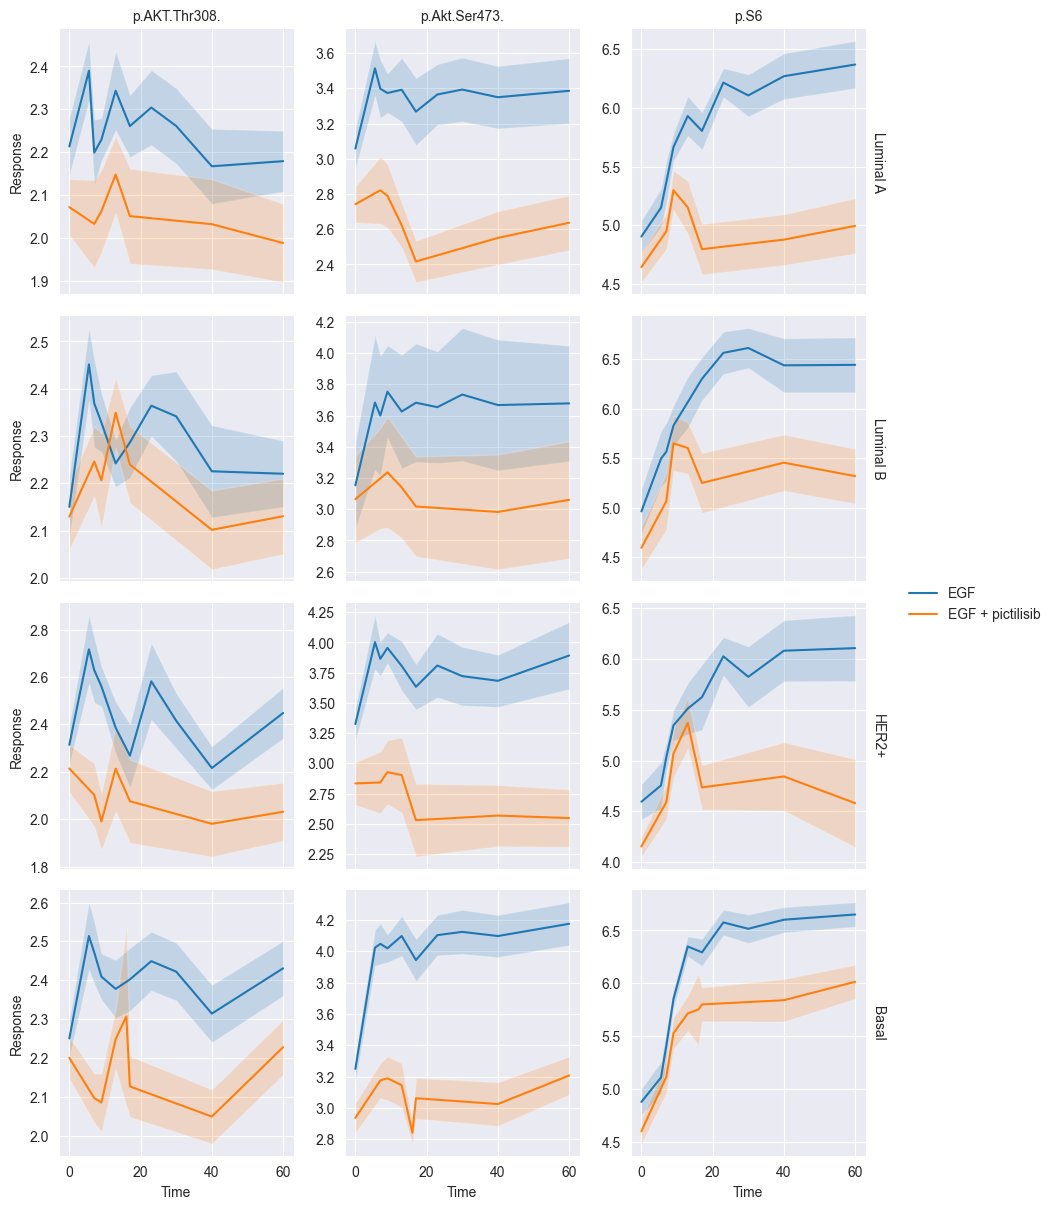

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# aggregate mean and std per lineage
dfp = (
    df_new[['treatment', 'time', 'observableId', 'lineage', 'measurement', 'isna']]
    .groupby(['treatment', 'time', 'observableId', 'lineage'])
    .agg(measurement_mean=('measurement', 'mean'),
         measurement_std=('measurement', 'std'),
         n=('measurement', 'count'),
         isna=('isna', 'sum'))
    .reset_index()
)

dfp['measurement_se'] = dfp['measurement_std'] / np.sqrt(dfp['n'])

# filter data
dfp_filtered = dfp[dfp['isna'] >= 4]

# create FacetGrid
g = sns.FacetGrid(
    data=dfp_filtered,
    row="lineage",
    row_order=["Luminal A", "Luminal B", "HER2+", "Basal"],
    col="observableId",
    margin_titles=True,
    sharey=False,
)

# map lineplots
def plot_with_shading(data, **kwargs):
    ax = plt.gca()
    for treatment, subdf in data.groupby("treatment"):
        ax.plot(subdf["time"], subdf["measurement_mean"], label=treatment)
        ax.fill_between(
            subdf["time"],
            subdf["measurement_mean"] - subdf["measurement_se"],
            subdf["measurement_mean"] + subdf["measurement_se"],
            alpha=0.2
        )

g.map_dataframe(plot_with_shading)
# Fix title templates
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Add axis labels
for ax in g.axes[-1, :]:  # bottom row
    ax.set_xlabel("Time")

for ax in g.axes[:, 0]:  # leftmost column
    ax.set_ylabel("Response")
g.add_legend()
# plt.savefig("updated_response_AKT_S6_PI3Ki_17LuminalAvs8LuminalBvs8HER2vs29Basal.pdf")